### Step 1: keep only stations with real coverage

We already verified the raw station list. The important point is that not every PM2.5 monitor is good enough.

We will use a measurable rule:

- calculate actual coverage_days = (last_reading - first_reading).days
- keep only stations where coverage_days >= 730

This is the minimum quality gate for version one.

A station with only a few months of data is too weak for a stable forecast.

In [1]:
import pandas as pd

stations = pd.read_csv("../data/raw/stations.csv")

stations["first_reading"] = pd.to_datetime(stations["first_reading"], errors="coerce")
stations["last_reading"] = pd.to_datetime(stations["last_reading"], errors="coerce")

stations["coverage_days"] = (
    stations["last_reading"] - stations["first_reading"]
).dt.days

valid_stations = stations[
    stations["coverage_days"] >= 730
].copy()

valid_stations = valid_stations.sort_values(
    by=["coverage_days", "last_reading"],
    ascending=[False, False]
).reset_index(drop=True)

print("Raw stations:", len(stations))
print("Valid stations:", len(valid_stations))
print("Unique valid locations:", valid_stations["location_id"].nunique())

display(valid_stations.head(10))

Raw stations: 147
Valid stations: 50
Unique valid locations: 50


,location_id,sensor_id,name,latitude,longitude,provider,first_reading,last_reading,coverage_days
0,8118,23534,New Delhi,28.635760,77.224450,AirNow,2016-11-10 00:30:00+05:30,2026-09-16 16:00:00+05:30,3597.0
1,301,1166,"Vikas Sadan, Gurugram - HSPCB",28.450124,77.026305,CPCB,2016-03-25 13:30:00+05:30,2022-10-31 07:30:00+05:30,2410.0
2,5610,14860,"North Campus, DU, Delhi - IMD",28.657381,77.158545,CPCB,2018-03-09 11:30:00+05:30,2022-10-31 07:30:00+05:30,1696.0
3,5617,14930,"Sector- 16A, Faridabad - HSPCB",28.408842,77.309908,caaqm,2018-03-09 11:30:00+05:30,2022-10-31 07:30:00+05:30,1696.0
4,5622,14922,"NSIT Dwarka, Delhi - CPCB",28.609090,77.032541,CPCB,2018-03-09 11:30:00+05:30,2022-10-31 07:30:00+05:30,1696.0
5,5630,14959,"Shadipur, Delhi - CPCB",28.651478,77.147311,CPCB,2018-03-09 11:30:00+05:30,2022-10-31 07:30:00+05:30,1696.0
6,5665,15239,"Vasundhara, Ghaziabad - UPPCB",28.660335,77.357256,CPCB,2018-03-09 11:30:00+05:30,2022-10-31 07:30:00+05:30,1696.0
7,5626,14985,"DTU, New Delhi - CPCB",28.750050,77.111261,CPCB,2018-03-09 11:00:00+05:30,2022-10-31 07:15:00+05:30,1696.0
8,5627,14935,"CRRI Mathura Road, New Delhi - IMD",28.551201,77.273574,CPCB,2018-03-09 11:00:00+05:30,2022-10-31 06:45:00+05:30,1696.0
9,5509,14521,"Anand Vihar, Delhi - DPCC",28.647622,77.315809,caaqm,2018-03-09 09:00:00+05:30,2022-10-31 06:00:00+05:30,1696.0


### What to read from this output

This tells us:

- the project is filtering out weak stations
- the valid pool is smaller and more trustworthy
- we now have the minimum-quality station list for the first model

This is the first hard quality gate.

### Step 2: use only the most recent 4 years

Now we choose the actual training time window.

For version one, we will use the most recent 4 years from the valid station pool.

Why:

- it matches the current Delhi environment
- it avoids very old data with different behavior
- it still gives enough history for seasonal learning

In [2]:
latest_reading = valid_stations["last_reading"].max()  # scan the whole column, keep only the single most recent date
print(latest_reading)  # show that one date
print(type(latest_reading))  # confirm it's one Timestamp, not a list/column

# latest_reading is a single Timestamp, not a collection -> count rows that match it
stations_on_latest_date = valid_stations[valid_stations["last_reading"] == latest_reading]  # rows: last_reading equals the max exactly
print("Stations with that exact latest reading:", len(stations_on_latest_date))  # how many rows matched

window_start = latest_reading - pd.DateOffset(years=4)  # go back 4 calendar years from the latest date

print("Latest available reading:", latest_reading)
print("Window start:", window_start)

recent_valid_stations = valid_stations[
    valid_stations["last_reading"] >= window_start  # keep rows whose last_reading falls on/after window_start
].copy()  # .copy() avoids a "view vs copy" warning when we edit this subset later

print("Stations in recent 4-year window:", len(recent_valid_stations))  # row count after the date filter
print("Unique locations in recent window:", recent_valid_stations["location_id"].nunique())  # distinct station IDs (no duplicates)

display(recent_valid_stations.head(10))  # preview first 10 rows of the filtered table

2026-09-16 16:30:00+05:30
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
Stations with that exact latest reading: 1
Latest available reading: 2026-09-16 16:30:00+05:30
Window start: 2022-09-16 16:30:00+05:30
Stations in recent 4-year window: 44
Unique locations in recent window: 44


,location_id,sensor_id,name,latitude,longitude,provider,first_reading,last_reading,coverage_days
0,8118,23534,New Delhi,28.635760,77.224450,AirNow,2016-11-10 00:30:00+05:30,2026-09-16 16:00:00+05:30,3597.0
1,301,1166,"Vikas Sadan, Gurugram - HSPCB",28.450124,77.026305,CPCB,2016-03-25 13:30:00+05:30,2022-10-31 07:30:00+05:30,2410.0
2,5610,14860,"North Campus, DU, Delhi - IMD",28.657381,77.158545,CPCB,2018-03-09 11:30:00+05:30,2022-10-31 07:30:00+05:30,1696.0
3,5617,14930,"Sector- 16A, Faridabad - HSPCB",28.408842,77.309908,caaqm,2018-03-09 11:30:00+05:30,2022-10-31 07:30:00+05:30,1696.0
4,5622,14922,"NSIT Dwarka, Delhi - CPCB",28.609090,77.032541,CPCB,2018-03-09 11:30:00+05:30,2022-10-31 07:30:00+05:30,1696.0
5,5630,14959,"Shadipur, Delhi - CPCB",28.651478,77.147311,CPCB,2018-03-09 11:30:00+05:30,2022-10-31 07:30:00+05:30,1696.0
6,5665,15239,"Vasundhara, Ghaziabad - UPPCB",28.660335,77.357256,CPCB,2018-03-09 11:30:00+05:30,2022-10-31 07:30:00+05:30,1696.0
7,5626,14985,"DTU, New Delhi - CPCB",28.750050,77.111261,CPCB,2018-03-09 11:00:00+05:30,2022-10-31 07:15:00+05:30,1696.0
8,5627,14935,"CRRI Mathura Road, New Delhi - IMD",28.551201,77.273574,CPCB,2018-03-09 11:00:00+05:30,2022-10-31 06:45:00+05:30,1696.0
9,5509,14521,"Anand Vihar, Delhi - DPCC",28.647622,77.315809,caaqm,2018-03-09 09:00:00+05:30,2022-10-31 06:00:00+05:30,1696.0


### What this means

This is the actual training-slice decision.

We are not using:

- all old stations
- all old dates
- every monitor that exists

We are using:

- only valid stations
- only the recent 4-year range
- the slice that is most relevant to the problem

### Step 3: save the filtered station list

We now save the filtered station list so the next notebook step can use it cleanly.

This makes the data pipeline reproducible.

In [3]:
from pathlib import Path

filtered_dir = Path("../data/processed")
filtered_dir.mkdir(parents=True, exist_ok=True)

filtered_stations_path = filtered_dir / "valid_stations_recent_4y.csv"
recent_valid_stations.to_csv(filtered_stations_path, index=False)

print("Saved filtered station list to:", filtered_stations_path)
print("Rows saved:", len(recent_valid_stations))
print("Columns saved:", list(recent_valid_stations.columns))

Saved filtered station list to: ../data/processed/valid_stations_recent_4y.csv
Rows saved: 44
Columns saved: ['location_id', 'sensor_id', 'name', 'latitude', 'longitude', 'provider', 'first_reading', 'last_reading', 'coverage_days']



### Step 4: use the filtered station list to build the real data slice

We have already done the hard gate:

- keep only stations with coverage_days >= 730
- keep only the most recent 4-year window

Now the next step is to turn that station list into the actual PM2.5 dataset.

The idea is simple:

- load the filtered station list
- keep only the valid location IDs
- fetch the PM2.5 readings for those locations
- keep only the recent date range
- build one table with station_id, date, pm25_value

This is the transition from station discovery to real forecasting data.
</VSCode.Cell>

In [4]:
import pandas as pd
from pathlib import Path

valid_stations = pd.read_csv("../data/processed/valid_stations_recent_4y.csv")

valid_stations["first_reading"] = pd.to_datetime(
    valid_stations["first_reading"], errors="coerce"
)
valid_stations["last_reading"] = pd.to_datetime(
    valid_stations["last_reading"], errors="coerce"
)

print("Valid station rows:", len(valid_stations))
print("Unique valid locations:", valid_stations["location_id"].nunique())

valid_location_ids = sorted(valid_stations["location_id"].unique().tolist())
print("Sample location ids:", valid_location_ids[:10])

selected_station_ids = valid_stations[["location_id", "sensor_id", "name"]].copy()
display(selected_station_ids.head(10))

Valid station rows: 44
Unique valid locations: 44
Sample location ids: [301, 5509, 5570, 5610, 5617, 5622, 5626, 5627, 5630, 5634]


,location_id,sensor_id,name
0,8118,23534,New Delhi
1,301,1166,"Vikas Sadan, Gurugram - HSPCB"
2,5610,14860,"North Campus, DU, Delhi - IMD"
3,5617,14930,"Sector- 16A, Faridabad - HSPCB"
4,5622,14922,"NSIT Dwarka, Delhi - CPCB"
5,5630,14959,"Shadipur, Delhi - CPCB"
6,5665,15239,"Vasundhara, Ghaziabad - UPPCB"
7,5626,14985,"DTU, New Delhi - CPCB"
8,5627,14935,"CRRI Mathura Road, New Delhi - IMD"
9,5509,14521,"Anand Vihar, Delhi - DPCC"



### What this gives us

This code does two important things:

- it loads the cleaned station list
- it prepares the exact station IDs we will use to fetch PM2.5 series

At this point, we are no longer guessing which stations are valid. We are using the station list that already passed the quality gate.



### Step 5: fetch the actual PM2.5 readings for those stations

The station file tells us which monitors are valid. The next move is to fetch the actual measurement history for those sensor IDs.

For this project, we will keep:

- station_id
- sensor_id
- date
- PM2.5 value
- source provider

Then we will reshape this into one daily table for modeling.




The fixed date range was only a placeholder. In real work, the date window should move with the latest available data.

We should not hardcode:
- date_from = "2022-09-16"
- date_to = "2026-09-16"

Instead, we use:
- latest available reading in the valid station list
- go back 4 years from that point
- search only that dynamic window

This keeps the dataset current and prevents future-date leakage.

In [5]:
import os
import time
import requests
import pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from dotenv import load_dotenv

load_dotenv()
headers = {"X-API-Key": os.getenv("OPENAQ_API_KEY")}

latest_reading = valid_stations["last_reading"].max()
window_start = latest_reading - pd.DateOffset(years=4)

date_from = window_start.strftime("%Y-%m-%d")
date_to = latest_reading.strftime("%Y-%m-%d")

print("Dynamic date_from:", date_from)
print("Dynamic date_to:", date_to)

# The fetch is the slow part of this notebook, so we do it once and keep the
# result on disk. Set REFETCH = True to pull fresh data from the API.
raw_cache_path = Path("../data/raw/pm25_daily_raw.csv")
REFETCH = False

PAGE_LIMIT = 1000  # the API caps a page at 1000 rows, so we must follow pages


def fetch_sensor_days(sensor_id):
    """Every daily row for one sensor in the window, following all pages."""
    rows = []
    page = 1

    while True:
        params = {
            "date_from": date_from,
            "date_to": date_to,
            "limit": PAGE_LIMIT,
            "page": page,
        }

        for attempt in range(5):
            response = requests.get(
                f"https://api.openaq.org/v3/sensors/{sensor_id}/days",
                headers=headers,
                params=params,
                timeout=30,
            )
            if response.status_code == 429:  # rate limited: back off and retry
                time.sleep(2 * (attempt + 1))
                continue
            break

        if response.status_code == 401:
            raise RuntimeError("Authentication failed: check the OpenAQ API key")

        if response.status_code != 200:
            print(f"Sensor {sensor_id} failed with HTTP {response.status_code}")
            break

        results = response.json().get("results", [])

        for row in results:
            value = row.get("value")
            if value is None:
                continue

            period = row.get("period") or {}
            date_local = (
                (period.get("datetimeFrom") or {}).get("local")
                or (period.get("datetimeTo") or {}).get("local")
            )

            if date_local is None:
                continue

            rows.append({
                "sensor_id": sensor_id,
                "date": date_local[:10],  # daily data, so the date part is the day
                "pm25_value": value,
            })

        if len(results) < PAGE_LIMIT:  # last page reached
            break

        page += 1

    return rows


if raw_cache_path.exists() and not REFETCH:
    station_measurements = pd.read_csv(raw_cache_path).to_dict("records")
    print("Loaded cached measurements from:", raw_cache_path)
else:
    sensor_ids = (
        selected_station_ids["sensor_id"].dropna().astype(int).unique().tolist()
    )

    # These calls wait on the network, not the CPU, so a few run at once.
    with ThreadPoolExecutor(max_workers=5) as pool:
        pages = pool.map(fetch_sensor_days, sensor_ids)
        station_measurements = [row for sensor_rows in pages for row in sensor_rows]

    raw_cache_path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(station_measurements).to_csv(raw_cache_path, index=False)
    print("Fetched from the API and cached to:", raw_cache_path)

print("Total PM2.5 rows fetched:", len(station_measurements))
print("Sensors represented:", len({row["sensor_id"] for row in station_measurements}))

Dynamic date_from: 2022-09-16
Dynamic date_to: 2026-09-16
Loaded cached measurements from: ../data/raw/pm25_daily_raw.csv
Total PM2.5 rows fetched: 3342
Sensors represented: 44


### What this does

This code fetches the actual daily PM2.5 readings for the valid sensors in the recent window.

The result is a raw measurement table that we can later convert into:

- daily station-level series
- feature matrix
- target column
- train/test split

We are now at the real data-building step, not just station discovery.


### Step 6: convert raw rows into one clean daily table

The raw sensor API output is messy. It has one row per day per sensor, but we need a cleaner table before building the forecasting target.

We will do three things:

- turn the raw list into a DataFrame
- parse the date column
- join the sensor back to its station metadata
- aggregate to one daily PM2.5 value per location

This gets us from raw API output to a model-ready table.

In [6]:
import pandas as pd

raw_measurements = pd.DataFrame(station_measurements)

print("Raw measurement rows:", len(raw_measurements))
print("Raw columns:", list(raw_measurements.columns))

if len(raw_measurements) > 0:
    raw_measurements["date"] = pd.to_datetime(raw_measurements["date"], errors="coerce")
    raw_measurements["pm25_value"] = pd.to_numeric(raw_measurements["pm25_value"], errors="coerce")

    raw_measurements = raw_measurements.dropna(subset=["date", "pm25_value"]).copy()
    print("After copy the raw measuremenets ", len(raw_measurements))


    raw_measurements = raw_measurements.merge(
        selected_station_ids[["location_id", "sensor_id", "name"]],
        on="sensor_id",
        how="left"
    )

    raw_measurements["date"] = raw_measurements["date"].dt.normalize()

    daily_pm25 = (
        raw_measurements
        .groupby(["location_id", "date"], as_index=False)["pm25_value"]
        .mean()
        .rename(columns={"pm25_value": "pm25_daily_mean"})
    )

    daily_pm25 = daily_pm25.sort_values(["location_id", "date"]).reset_index(drop=True)

    print("Clean daily rows:", len(daily_pm25))
    print("Unique locations:", daily_pm25["location_id"].nunique())
    display(daily_pm25.head(10))
else:
    print("No measurement rows were fetched.")

Raw measurement rows: 3342
Raw columns: ['sensor_id', 'date', 'pm25_value']
After copy the raw measuremenets  3342
Clean daily rows: 3342
Unique locations: 44


,location_id,date,pm25_daily_mean
0,301,2022-10-07,43.40
1,301,2022-10-08,10.00
2,301,2022-10-09,9.91
3,301,2022-10-10,20.80
4,301,2022-10-11,25.60
5,301,2022-10-12,37.80
6,301,2022-10-13,45.60
7,301,2022-10-14,56.70
8,301,2022-10-15,76.40
9,301,2022-10-16,73.70


### Visual check: how sensor readings become one location-day value

Before moving on, let us look at one real location. Every location in our filtered station list carries a single PM2.5 sensor, so the `groupby` mean is a pass-through: the daily mean equals the one reading behind it.

The cell below checks that instead of assuming it. If any location-day ever does have several sensors, it draws the bars and the mean they collapse into; otherwise it shows the pass-through directly.

Most sensors on any single location-day: 1


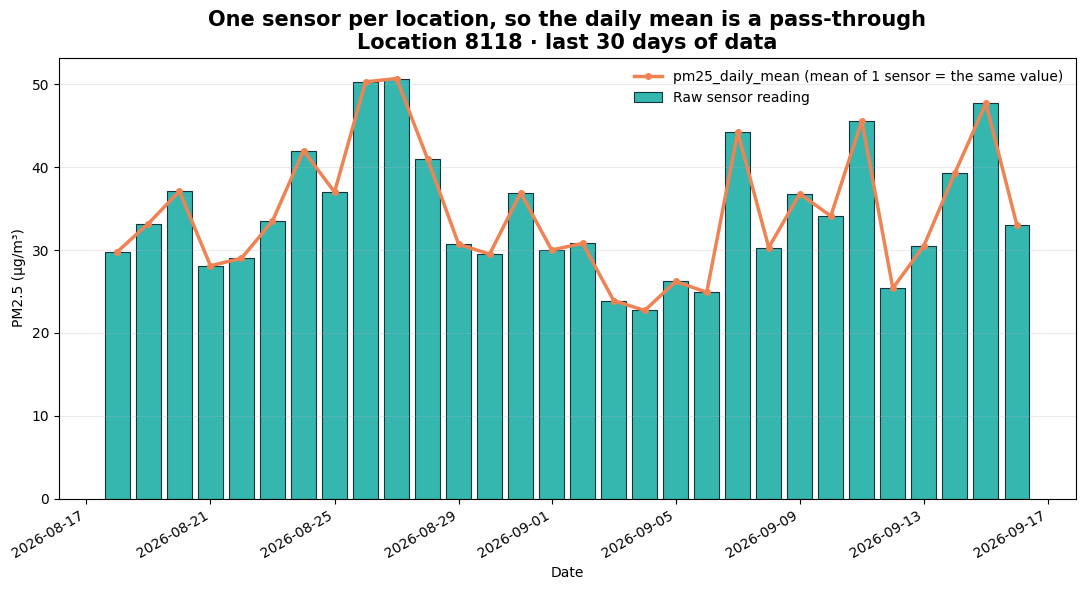

Location shown: 8118
Locations in the table: 44
Sensors in the table: 44


In [7]:
import matplotlib.pyplot as plt

if len(raw_measurements) == 0:
    print("No measurement rows were fetched, so there is nothing to visualize.")
else:
    sensors_per_location_day = (
        raw_measurements
        .groupby(["location_id", "date"])["sensor_id"]
        .nunique()
    )
    busiest_count = sensors_per_location_day.max()
    print("Most sensors on any single location-day:", busiest_count)

    if busiest_count >= 2:
        # Several sensors really do share a location-day: show them collapsing
        # into the one mean that daily_pm25 stores.
        selected_location, selected_date = sensors_per_location_day.idxmax()

        sensor_day = (
            raw_measurements[
                (raw_measurements["location_id"] == selected_location)
                & (raw_measurements["date"] == selected_date)
            ][["sensor_id", "pm25_value"]]
            .sort_values("sensor_id")
        )
        location_day_mean = sensor_day["pm25_value"].mean()

        figure, axis = plt.subplots(figsize=(11, 6))
        bars = axis.bar(
            sensor_day["sensor_id"].astype(str),
            sensor_day["pm25_value"],
            color="#35b7b0",
            edgecolor="#12343b",
            linewidth=1.2,
            label="Individual sensor readings",
        )
        axis.axhline(
            location_day_mean,
            color="#ef8354",
            linestyle="--",
            linewidth=2.5,
            label=f"Mean stored in daily_pm25 = {location_day_mean:.2f} µg/m³",
        )
        axis.bar_label(bars, fmt="%.1f", padding=4, fontsize=10)
        axis.set_title(
            f"{len(sensor_day)} sensors becoming one location-day mean\n"
            f"Location {selected_location} · {selected_date:%Y-%m-%d}",
            fontsize=15,
            fontweight="bold",
        )
        axis.set_xlabel("Sensor ID")
        axis.set_ylabel("PM2.5 (µg/m³)")
    else:
        # Every location in this station list carries exactly one PM2.5 sensor,
        # so the groupby mean is a pass-through. Show that honestly instead of
        # pretending several sensors are being averaged.
        selected_location = (
            raw_measurements["location_id"].value_counts().idxmax()
        )
        location_rows = (
            raw_measurements[raw_measurements["location_id"] == selected_location]
            .sort_values("date")
            .tail(30)
        )
        matching_daily = daily_pm25[
            (daily_pm25["location_id"] == selected_location)
            & (daily_pm25["date"].isin(location_rows["date"]))
        ].sort_values("date")

        figure, axis = plt.subplots(figsize=(11, 6))
        axis.bar(
            location_rows["date"],
            location_rows["pm25_value"],
            color="#35b7b0",
            edgecolor="#12343b",
            linewidth=0.8,
            label="Raw sensor reading",
        )
        axis.plot(
            matching_daily["date"],
            matching_daily["pm25_daily_mean"],
            color="#ef8354",
            linewidth=2.5,
            marker="o",
            markersize=4,
            label="pm25_daily_mean (mean of 1 sensor = the same value)",
        )
        axis.set_title(
            "One sensor per location, so the daily mean is a pass-through\n"
            f"Location {selected_location} · last 30 days of data",
            fontsize=15,
            fontweight="bold",
        )
        axis.set_xlabel("Date")
        axis.set_ylabel("PM2.5 (µg/m³)")
        figure.autofmt_xdate()

    axis.grid(axis="y", alpha=0.25)
    axis.legend(frameon=False)
    figure.tight_layout()
    plt.show()

    print("Location shown:", selected_location)
    print("Locations in the table:", raw_measurements["location_id"].nunique())
    print("Sensors in the table:", raw_measurements["sensor_id"].nunique())


### What this output means

This is the first real clean table.

At this point we have:

- one row per location per date
- one PM2.5 daily mean value
- a structure that is much easier to model

This table is no longer raw API output. It is now the working dataset for forecasting.

